**Chương 12 – Các Mô hình Tùy chỉnh và Huấn luyện với TensorFlow**

_Tập notebook này chứa tất cả các mã mẫu và lời giải cho các bài tập trong chương 12, cũng như các ví dụ mã từ Phụ lục C_

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/12_custom_models_and_training_with_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/12_custom_models_and_training_with_tensorflow.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Thiết lập

Dự án này yêu cầu **Python 3.7** hoặc cao hơn:

In [916]:
import sys

assert sys.version_info >= (3, 7)

Và **TensorFlow $\geq$ 2.8**:

In [917]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

## Sử dụng TensorFlow giống như NumPy

### Các Tensor và Phép toán

#### Tensors

In [918]:
t = tf.constant([[1., 2., 3.], [4., 5., 6.]]) # matrix
t

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [919]:
t.shape

TensorShape([2, 3])

In [920]:
t.dtype

tf.float32

#### Đánh chỉ mục

In [921]:
t[:, 1:]

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 3.],
       [5., 6.]], dtype=float32)>

In [922]:
t[..., 1, tf.newaxis]

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [5.]], dtype=float32)>

#### Phép toán

In [923]:
t + 10

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[11., 12., 13.],
       [14., 15., 16.]], dtype=float32)>

In [924]:
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

In [925]:
t @ tf.transpose(t)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[14., 32.],
       [32., 77.]], dtype=float32)>

#### Scalars

In [926]:
tf.constant(42)

<tf.Tensor: shape=(), dtype=int32, numpy=42>

#### API cấp thấp của Keras

Bạn vẫn có thể bắt gặp mã sử dụng **API cấp thấp** của Keras:

In [927]:
K = tf.keras.backend
K.square(K.transpose(t)) + 10

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[11., 26.],
       [14., 35.],
       [19., 46.]], dtype=float32)>

Nhưng vì **Keras** không còn hỗ trợ nhiều **backend** nữa, thay vào đó bạn nên sử dụng trực tiếp **API cấp thấp** của **TensorFlow**:

In [928]:
tf.square(tf.transpose(t)) + 10

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[11., 26.],
       [14., 35.],
       [19., 46.]], dtype=float32)>

### Các Tensor và NumPy

In [929]:
import numpy as np

a = np.array([2., 4., 5.])
tf.constant(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([2., 4., 5.])>

In [930]:
t.numpy()

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [931]:
np.array(t)

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [932]:
tf.square(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 4., 16., 25.])>

In [933]:
np.square(t)

array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)

### Chuyển đổi Kiểu

In [934]:
try:
    tf.constant(2.0) + tf.constant(40)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 


In [935]:
try:
    tf.constant(2.0) + tf.constant(40., dtype=tf.float64)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:AddV2] name: 


In [936]:
t2 = tf.constant(40., dtype=tf.float64)
tf.constant(2.0) + tf.cast(t2, tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=42.0>

### Biến số

In [937]:
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])
v

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [938]:
v.assign(2 * v)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2.,  4.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [939]:
v[0, 1].assign(42)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [940]:
v[:, 2].assign([0., 1.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  0.],
       [ 8., 10.,  1.]], dtype=float32)>

In [941]:
v.scatter_nd_update(
    indices=[[0, 0], [1, 2]], updates=[100., 200.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[100.,  42.,   0.],
       [  8.,  10., 200.]], dtype=float32)>

In [942]:
# extra code – shows how to use scatter_update()
sparse_delta = tf.IndexedSlices(values=[[1., 2., 3.], [4., 5., 6.]],
                                indices=[1, 0])
v.scatter_update(sparse_delta)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[4., 5., 6.],
       [1., 2., 3.]], dtype=float32)>

In [943]:
try:
    v[1] = [7., 8., 9.]
except TypeError as ex:
    print(ex)

'ResourceVariable' object does not support item assignment


### Chuỗi

Mã trong phần này và tất cả các phần tiếp theo trong **Phụ lục C**

In [944]:
tf.constant(b"hello world")

<tf.Tensor: shape=(), dtype=string, numpy=b'hello world'>

In [945]:
tf.constant("café")

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

In [946]:
u = tf.constant([ord(c) for c in "café"])
u

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

In [947]:
b = tf.strings.unicode_encode(u, "UTF-8")
tf.strings.length(b, unit="UTF8_CHAR")

<tf.Tensor: shape=(), dtype=int32, numpy=4>

In [948]:
tf.strings.unicode_decode(b, "UTF-8")

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

### Các Cấu trúc Dữ liệu Khác

Mã trong phần này nằm ở **Phụ lục C**.

#### Mảng Chuỗi

In [949]:
tf.constant(b"hello world")

<tf.Tensor: shape=(), dtype=string, numpy=b'hello world'>

In [950]:
tf.constant("café")

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

In [951]:
u = tf.constant([ord(c) for c in "café"])
u

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

In [952]:
b = tf.strings.unicode_encode(u, "UTF-8")
b

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

In [953]:
tf.strings.length(b, unit="UTF8_CHAR")

<tf.Tensor: shape=(), dtype=int32, numpy=4>

In [954]:
tf.strings.unicode_decode(b, "UTF-8")

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

In [955]:
p = tf.constant(["Café", "Coffee", "caffè", "咖啡"])

In [956]:
tf.strings.length(p, unit="UTF8_CHAR")

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([4, 6, 5, 2], dtype=int32)>

In [957]:
r = tf.strings.unicode_decode(p, "UTF8")
r

<tf.RaggedTensor [[67, 97, 102, 233], [67, 111, 102, 102, 101, 101],
 [99, 97, 102, 102, 232], [21654, 21857]]>

#### Tensor Lởm chởm

In [958]:
r[1]

<tf.Tensor: shape=(6,), dtype=int32, numpy=array([ 67, 111, 102, 102, 101, 101], dtype=int32)>

In [959]:
r[1:3]  # extra code – a slice of a ragged tensor is a ragged tensor

<tf.RaggedTensor [[67, 111, 102, 102, 101, 101], [99, 97, 102, 102, 232]]>

In [960]:
r2 = tf.ragged.constant([[65, 66], [], [67]])
tf.concat([r, r2], axis=0)

<tf.RaggedTensor [[67, 97, 102, 233], [67, 111, 102, 102, 101, 101],
 [99, 97, 102, 102, 232], [21654, 21857], [65, 66], [], [67]]>

In [961]:
r3 = tf.ragged.constant([[68, 69, 70], [71], [], [72, 73]])
print(tf.concat([r, r3], axis=1))

<tf.RaggedTensor [[67, 97, 102, 233, 68, 69, 70], [67, 111, 102, 102, 101, 101, 71],
 [99, 97, 102, 102, 232], [21654, 21857, 72, 73]]>


In [962]:
r.to_tensor()

<tf.Tensor: shape=(4, 6), dtype=int32, numpy=
array([[   67,    97,   102,   233,     0,     0],
       [   67,   111,   102,   102,   101,   101],
       [   99,    97,   102,   102,   232,     0],
       [21654, 21857,     0,     0,     0,     0]], dtype=int32)>

#### Tensor Thưa thớt

In [963]:
s = tf.SparseTensor(indices=[[0, 1], [1, 0], [2, 3]],
                    values=[1., 2., 3.],
                    dense_shape=[3, 4])

In [964]:
tf.sparse.to_dense(s)

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 1., 0., 0.],
       [2., 0., 0., 0.],
       [0., 0., 0., 3.]], dtype=float32)>

In [965]:
s * 42.0

SparseTensor(indices=tf.Tensor(
[[0 1]
 [1 0]
 [2 3]], shape=(3, 2), dtype=int64), values=tf.Tensor([ 42.  84. 126.], shape=(3,), dtype=float32), dense_shape=tf.Tensor([3 4], shape=(2,), dtype=int64))

In [966]:
try:
    s + 42.0
except TypeError as ex:
    print(ex)

unsupported operand type(s) for +: 'SparseTensor' and 'float'


In [967]:
# extra code – shows how to multiply a sparse tensor and a dense tensor
s4 = tf.constant([[10., 20.], [30., 40.], [50., 60.], [70., 80.]])
tf.sparse.sparse_dense_matmul(s, s4)

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 30.,  40.],
       [ 20.,  40.],
       [210., 240.]], dtype=float32)>

In [968]:
# extra code – when creating a sparse tensor, values must be given in "reading
#              order", or else `to_dense()` will fail.
s5 = tf.SparseTensor(indices=[[0, 2], [0, 1]],  # WRONG ORDER!
                     values=[1., 2.],
                     dense_shape=[3, 4])
try:
    tf.sparse.to_dense(s5)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

{{function_node __wrapped__SparseToDense_device_/job:localhost/replica:0/task:0/device:CPU:0}} indices[1] = [0,1] is out of order. Many sparse ops require sorted indices.
    Use `tf.sparse.reorder` to create a correctly ordered copy.

 [Op:SparseToDense] name: 


In [969]:
# extra code – shows how to fix the sparse tensor s5 by reordering its values
s6 = tf.sparse.reorder(s5)
tf.sparse.to_dense(s6)

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 2., 1., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

#### Mảng Tensor

In [970]:
array = tf.TensorArray(dtype=tf.float32, size=3)
array = array.write(0, tf.constant([1., 2.]))
array = array.write(1, tf.constant([3., 10.]))
array = array.write(2, tf.constant([5., 7.]))
tensor1 = array.read(1)  # returns (and zeros out!) tf.constant([3., 10.])

In [971]:
array.stack()

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 2.],
       [0., 0.],
       [5., 7.]], dtype=float32)>

In [972]:
# extra code – shows how to disable clear_after_read
array2 = tf.TensorArray(dtype=tf.float32, size=3, clear_after_read=False)
array2 = array2.write(0, tf.constant([1., 2.]))
array2 = array2.write(1, tf.constant([3., 10.]))
array2 = array2.write(2, tf.constant([5., 7.]))
tensor2 = array2.read(1)  # returns tf.constant([3., 10.])
array2.stack()

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 1.,  2.],
       [ 3., 10.],
       [ 5.,  7.]], dtype=float32)>

In [973]:
# extra code – shows how to create and use a tensor array with a dynamic size
array3 = tf.TensorArray(dtype=tf.float32, size=0, dynamic_size=True)
array3 = array3.write(0, tf.constant([1., 2.]))
array3 = array3.write(1, tf.constant([3., 10.]))
array3 = array3.write(2, tf.constant([5., 7.]))
tensor3 = array3.read(1)
array3.stack()

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 2.],
       [0., 0.],
       [5., 7.]], dtype=float32)>

#### Tập hợp

In [974]:
a = tf.constant([[1, 5, 9]])
b = tf.constant([[5, 6, 9, 11]])
u = tf.sets.union(a, b)
u

SparseTensor(indices=tf.Tensor(
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]], shape=(5, 2), dtype=int64), values=tf.Tensor([ 1  5  6  9 11], shape=(5,), dtype=int32), dense_shape=tf.Tensor([1 5], shape=(2,), dtype=int64))

In [975]:
tf.sparse.to_dense(u)

<tf.Tensor: shape=(1, 5), dtype=int32, numpy=array([[ 1,  5,  6,  9, 11]], dtype=int32)>

In [976]:
a = tf.constant([[1, 5, 9], [10, 0, 0]])
b = tf.constant([[5, 6, 9, 11], [13, 0, 0, 0]])
u = tf.sets.union(a, b)
tf.sparse.to_dense(u)

<tf.Tensor: shape=(2, 5), dtype=int32, numpy=
array([[ 1,  5,  6,  9, 11],
       [ 0, 10, 13,  0,  0]], dtype=int32)>

In [977]:
# extra code – shows how to use a different default value: -1 in this case
a = tf.constant([[1, 5, 9], [10, -1, -1]])
b = tf.constant([[5, 6, 9, 11], [13, -1, -1, -1]])
u = tf.sets.union(a, b)
tf.sparse.to_dense(u, default_value=-1)

<tf.Tensor: shape=(2, 5), dtype=int32, numpy=
array([[ 1,  5,  6,  9, 11],
       [-1, 10, 13, -1, -1]], dtype=int32)>

In [978]:
# extra code – shows how to use `tf.sets.difference()`
set1 = tf.constant([[2, 3, 5, 7], [7, 9, 0, 0]])
set2 = tf.constant([[4, 5, 6], [9, 10, 0]])
tf.sparse.to_dense(tf.sets.difference(set1, set2))

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[2, 3, 7],
       [7, 0, 0]], dtype=int32)>

In [979]:
# extra code – shows how to use `tf.sets.difference()`
tf.sparse.to_dense(tf.sets.intersection(set1, set2))

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[5, 0],
       [0, 9]], dtype=int32)>

In [980]:
# extra code – check whether set1[0] contains 5
tf.sets.size(tf.sets.intersection(set1[:1], tf.constant([[5, 0, 0, 0]]))) > 0

<tf.Tensor: shape=(1,), dtype=bool, numpy=array([ True])>

#### Hàng đợi

In [981]:
q = tf.queue.FIFOQueue(3, [tf.int32, tf.string], shapes=[(), ()])
q.enqueue([10, b"windy"])
q.enqueue([15, b"sunny"])
q.size()

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [982]:
q.dequeue()

[<tf.Tensor: shape=(), dtype=int32, numpy=10>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'windy'>]

In [983]:
q.enqueue_many([[13, 16], [b'cloudy', b'rainy']])

In [984]:
q.dequeue_many(3)

[<tf.Tensor: shape=(3,), dtype=int32, numpy=array([15, 13, 16], dtype=int32)>,
 <tf.Tensor: shape=(3,), dtype=string, numpy=array([b'sunny', b'cloudy', b'rainy'], dtype=object)>]

## Hàm lỗi Tùy chỉnh

In [985]:
def huber_fn(y_true, y_pred):
    error = y_true - y_pred
    is_small_error = tf.abs(error) < 1
    squared_loss = tf.square(error) / 2
    linear_loss  = tf.abs(error) - 0.5
    return tf.where(is_small_error, squared_loss, linear_loss)

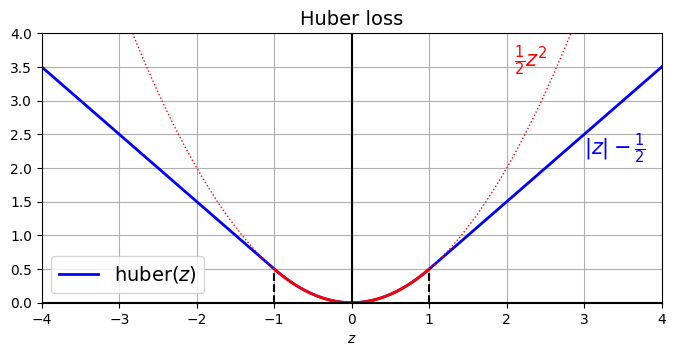

In [986]:
# extra code – shows what the Huber loss looks like

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3.5))
z = np.linspace(-4, 4, 200)
z_center = np.linspace(-1, 1, 200)
plt.plot(z, huber_fn(0, z), "b-", linewidth=2, label="huber($z$)")
plt.plot(z, z ** 2 / 2, "r:", linewidth=1)
plt.plot(z_center, z_center ** 2 / 2, "r", linewidth=2)
plt.plot([-1, -1], [0, huber_fn(0., -1.)], "k--")
plt.plot([1, 1], [0, huber_fn(0., 1.)], "k--")
plt.gca().axhline(y=0, color='k')
plt.gca().axvline(x=0, color='k')
plt.text(2.1, 3.5, r"$\frac{1}{2}z^2$", color="r", fontsize=15)
plt.text(3.0, 2.2, r"$|z| - \frac{1}{2}$", color="b", fontsize=15)
plt.axis([-4, 4, 0, 4])
plt.grid(True)
plt.xlabel("$z$")
plt.legend(fontsize=14)
plt.title("Huber loss", fontsize=14)
plt.show()

Để kiểm tra **hàm lỗi tùy chỉnh** của chúng ta, hãy tạo một mô hình Keras cơ bản và huấn luyện nó trên **tập dữ liệu nhà ở California**:

In [987]:
# extra code – loads, splits and scales the California housing dataset, then
#              creates a simple Keras model

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target.reshape(-1, 1), random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

input_shape = X_train.shape[1:]

tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [988]:
model.compile(loss=huber_fn, optimizer="nadam", metrics=["mae"])

In [989]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7494 - mae: 1.1371 - val_loss: 0.3474 - val_mae: 0.6522
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2607 - mae: 0.5681 - val_loss: 0.2553 - val_mae: 0.5383


## Lưu/Tải Mô hình với các Đối tượng Tùy chỉnh

In [990]:
#model.save("my_model_with_a_custom_loss")  # extra code – saving works fine
model.save("my_model_with_a_custom_loss.keras")


In [991]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss.keras",
                                   custom_objects={"huber_fn": huber_fn})

In [992]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2188 - mae: 0.5096 - val_loss: 0.2129 - val_mae: 0.4876
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1990 - mae: 0.4809 - val_loss: 0.1891 - val_mae: 0.4610


In [993]:
def create_huber(threshold=1.0):
    def huber_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < threshold
        squared_loss = tf.square(error) / 2
        linear_loss  = threshold * tf.abs(error) - threshold ** 2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_fn

In [994]:
model.compile(loss=create_huber(2.0), optimizer="nadam", metrics=["mae"])

In [995]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.2148 - mae: 0.4689 - val_loss: 0.2084 - val_mae: 0.4504
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2054 - mae: 0.4597 - val_loss: 0.1807 - val_mae: 0.4340


In [996]:
model.save("my_model_with_a_custom_loss_threshold_2.keras")

In [997]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss_threshold_2.keras",
                                   custom_objects={"huber_fn": create_huber(2.0)})

In [998]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2000 - mae: 0.4540 - val_loss: 0.1853 - val_mae: 0.4339
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1959 - mae: 0.4490 - val_loss: 0.1976 - val_mae: 0.4367


In [999]:
class HuberLoss(tf.keras.losses.Loss):
    def __init__(self, threshold=1.0, **kwargs):
        self.threshold = threshold
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < self.threshold
        squared_loss = tf.square(error) / 2
        linear_loss  = self.threshold * tf.abs(error) - self.threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

In [1000]:
# extra code – creates another basic Keras model
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

In [1001]:
model.compile(loss=HuberLoss(2.), optimizer="nadam", metrics=["mae"])

In [1002]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0512 - mae: 1.1438 - val_loss: 0.5086 - val_mae: 0.6718
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3170 - mae: 0.5816 - val_loss: 0.3527 - val_mae: 0.5571


In [1003]:
model.save("my_model_with_a_custom_loss_class.keras")  # extra code – saving works

In [1004]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss_class.keras",
                                   custom_objects={"HuberLoss": HuberLoss})

In [1005]:
# extra code – shows that loading worked fine, the model can be used normally
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2612 - mae: 0.5244 - val_loss: 0.2689 - val_mae: 0.4982
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2328 - mae: 0.4929 - val_loss: 0.2207 - val_mae: 0.4657


In [1006]:
model.loss.threshold  # extra code – the treshold was loaded correctly

2.0

## Các Hàm Tùy chỉnh Khác

In [1007]:
def my_softplus(z):
    return tf.math.log(1.0 + tf.exp(z))

def my_glorot_initializer(shape, dtype=tf.float32):
    stddev = tf.sqrt(2. / (shape[0] + shape[1]))
    return tf.random.normal(shape, stddev=stddev, dtype=dtype)

def my_l1_regularizer(weights):
    return tf.reduce_sum(tf.abs(0.01 * weights))

def my_positive_weights(weights):  # return value is just tf.nn.relu(weights)
    return tf.where(weights < 0., tf.zeros_like(weights), weights)

In [1008]:
layer = tf.keras.layers.Dense(1, activation=my_softplus,
                              kernel_initializer=my_glorot_initializer,
                              kernel_regularizer=my_l1_regularizer,
                              kernel_constraint=my_positive_weights)

In [1009]:
# extra code – show that building, training, saving, loading, and training again
#              works fine with a model containing many custom parts

# tf.keras.utils.set_random_seed(42)
# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
#                           input_shape=input_shape),
#     tf.keras.layers.Dense(1, activation=my_softplus,
#                           kernel_initializer=my_glorot_initializer,
#                           kernel_regularizer=my_l1_regularizer,
#                           kernel_constraint=my_positive_weights)
# ])
# model.compile(loss="mse", optimizer="nadam", metrics=["mae"])
# model.fit(X_train_scaled, y_train, epochs=2,
#           validation_data=(X_valid_scaled, y_valid))
# model.save("my_model_with_many_custom_parts")
# model = tf.keras.models.load_model(
#     "my_model_with_many_custom_parts",
#     custom_objects={
#        "my_l1_regularizer": my_l1_regularizer,
#        "my_positive_weights": my_positive_weights,
#        "my_glorot_initializer": my_glorot_initializer,
#        "my_softplus": my_softplus,
#     }
# )
# model.fit(X_train_scaled, y_train, epochs=2,
#           validation_data=(X_valid_scaled, y_valid))

class HuberLoss(tf.keras.losses.Loss):
    def __init__(self, threshold=1.0, **kwargs):
        super().__init__(**kwargs)
        self.threshold = threshold

    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) <= self.threshold
        small_error_loss = 0.5 * tf.square(error)
        big_error_loss = self.threshold * (tf.abs(error) - 0.5 * self.threshold)
        return tf.where(is_small_error, small_error_loss, big_error_loss)

    def get_config(self):
        config = super().get_config()
        config.update({"threshold": self.threshold})
        return config

class MyL1Regularizer(tf.keras.regularizers.Regularizer):
    def __init__(self, factor=0.01):
        self.factor = factor

    def __call__(self, weights):
        return tf.reduce_sum(tf.abs(self.factor * weights))

    def get_config(self):
        return {"factor": self.factor}

tf.keras.layers.Dense(
    1,
    activation=my_softplus,
    kernel_initializer=my_glorot_initializer,
    kernel_regularizer=MyL1Regularizer(0.01),  # ✅ dùng lớp custom
    kernel_constraint=my_positive_weights
)
model.save("my_model_with_many_custom_parts.keras")

model = tf.keras.models.load_model(
    "my_model_with_many_custom_parts.keras",
    custom_objects={
        "HuberLoss": HuberLoss,                    # 👈 thêm dòng này
        "MyL1Regularizer": MyL1Regularizer,
        "my_positive_weights": my_positive_weights,
        "my_glorot_initializer": my_glorot_initializer,
        "my_softplus": my_softplus
    }
)




In [1010]:
class MyL1Regularizer(tf.keras.regularizers.Regularizer):
    def __init__(self, factor):
        self.factor = factor

    def __call__(self, weights):
        return tf.reduce_sum(tf.abs(self.factor * weights))

    def get_config(self):
        return {"factor": self.factor}

In [1011]:
# extra code – again, show that everything works fine, this time using our
#              custom regularizer class

# tf.keras.utils.set_random_seed(42)
# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
#                           input_shape=input_shape),
#     tf.keras.layers.Dense(1, activation=my_softplus,
#                           kernel_regularizer=MyL1Regularizer(0.01),
#                           kernel_constraint=my_positive_weights,
#                           kernel_initializer=my_glorot_initializer),
# ])
# model.compile(loss="mse", optimizer="nadam", metrics=["mae"])
# model.fit(X_train_scaled, y_train, epochs=2,
#           validation_data=(X_valid_scaled, y_valid))
# model.save("my_model_with_many_custom_parts")
# model = tf.keras.models.load_model(
#     "my_model_with_many_custom_parts",
#     custom_objects={
#        "MyL1Regularizer": MyL1Regularizer,
#        "my_positive_weights": my_positive_weights,
#        "my_glorot_initializer": my_glorot_initializer,
#        "my_softplus": my_softplus,
#     }
# )
# model.fit(X_train_scaled, y_train, epochs=2,
#           validation_data=(X_valid_scaled, y_valid))

import tensorflow as tf
import numpy as np

# ===== 1) Custom objects (đăng ký đúng cách cho tf.keras) =====
@tf.keras.utils.register_keras_serializable(package="custom")
class MyL1Regularizer(tf.keras.regularizers.Regularizer):
    def __init__(self, factor=0.01):
        self.factor = factor
    def __call__(self, w):
        return tf.reduce_sum(tf.abs(self.factor * w))
    def get_config(self):
        return {"factor": self.factor}

@tf.keras.utils.register_keras_serializable(package="custom")
class MyPositiveWeights(tf.keras.constraints.Constraint):
    def __call__(self, w):
        return tf.nn.relu(w)
    def get_config(self):
        return {}

@tf.keras.utils.register_keras_serializable(package="custom")
def my_softplus(x):
    # phiên bản ổn định số
    return tf.math.log1p(tf.exp(-tf.abs(x))) + tf.maximum(0., x)

@tf.keras.utils.register_keras_serializable(package="custom")
def my_glorot_initializer(shape, dtype=None):
    # Glorot uniform thủ công
    shape = tf.convert_to_tensor(shape)
    fan_in = tf.cast(tf.reduce_prod(shape[:-1]), tf.float32)
    fan_out = tf.cast(shape[-1], tf.float32)
    limit = tf.sqrt(6.0 / (fan_in + fan_out))
    return tf.random.uniform(shape, -limit, limit, dtype=dtype or tf.float32)

# ===== 2) Dữ liệu giả để chạy demo (thay bằng dữ liệu thật của bạn) =====
X_train_scaled = np.random.rand(1000, 5).astype("float32")
y_train        = np.random.rand(1000, 1).astype("float32")
X_valid_scaled = np.random.rand(200, 5).astype("float32")
y_valid        = np.random.rand(200, 1).astype("float32")
input_shape    = [5]

# ===== 3) Build → train → save (.keras) =====
tf.keras.utils.set_random_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu",
                          kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(
        1,
        activation=my_softplus,
        kernel_regularizer=MyL1Regularizer(0.01),
        kernel_constraint=MyPositiveWeights(),
        kernel_initializer=my_glorot_initializer,
    ),
])

model.compile(loss="mse", optimizer="nadam", metrics=["mae"])
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid), verbose=1)

model.save("my_model_with_many_custom_parts.keras")  # ✅ phải có .keras

# ===== 4) Load → train tiếp =====
# Nhờ đã register_keras_serializable, KHÔNG cần custom_objects:
model = tf.keras.models.load_model("my_model_with_many_custom_parts.keras")

# (Nếu môi trường cũ không nhận decorator, dùng bản fallback sau:)
# model = tf.keras.models.load_model(
#     "my_model_with_many_custom_parts.keras",
#     custom_objects={
#         "MyL1Regularizer": MyL1Regularizer,
#         "MyPositiveWeights": MyPositiveWeights,
#         "my_softplus": my_softplus,
#         "my_glorot_initializer": my_glorot_initializer,
#     }
# )

model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid), verbose=1)



Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.6073 - mae: 0.6746 - val_loss: 0.4345 - val_mae: 0.5662
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4458 - mae: 0.5698 - val_loss: 0.2955 - val_mae: 0.4457
Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3134 - mae: 0.4615 - val_loss: 0.2249 - val_mae: 0.3770
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2433 - mae: 0.3994 - val_loss: 0.1837 - val_mae: 0.3353


## Các Chỉ số Đánh giá Tùy chỉnh

In [1012]:
# extra code – once again, lets' create a basic Keras model
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

In [1013]:
model.compile(loss="mse", optimizer="nadam", metrics=[create_huber(2.0)])

In [1014]:
# extra code – train the model with our custom metric
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber_fn: 0.0938 - loss: 0.1875
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - huber_fn: 0.0620 - loss: 0.1241


**Lưu ý**: nếu bạn sử dụng cùng một hàm làm **hàm lỗi** và một **chỉ số đánh giá (metric)**, bạn có thể ngạc nhiên khi thấy kết quả hơi khác nhau. Điều này một phần là do các phép toán không được tính toán theo cùng một thứ tự chính xác, vì vậy có thể có các lỗi dấu phẩy động (floating point errors) rất nhỏ. Quan trọng hơn, nếu bạn sử dụng **trọng số mẫu (sample weights)** hoặc **trọng số lớp (class weights)**, thì các công thức sẽ hơi khác nhau:
* phương thức **`fit()`** theo dõi giá trị trung bình của tất cả các batch loss (lỗi theo lô) đã thấy kể từ đầu epoch (kỷ nguyên). Mỗi batch loss là tổng của các tổn thất của từng mẫu đã được nhân trọng số (weighted instance losses) chia cho **_batch size_** (không phải tổng trọng số, vì vậy batch loss **không phải** là trung bình có trọng số của các tổn thất).
* chỉ số đánh giá (metric) kể từ đầu epoch bằng tổng của các tổn thất của từng mẫu đã được nhân trọng số (weighted instance losses) chia cho tổng của tất cả các trọng số đã thấy cho đến nay. Nói cách khác, đó là **trung bình có trọng số** của tất cả các tổn thất của từng mẫu. Không phải là cùng một thứ.

### Các chỉ số đánh giá theo luồng (Streaming metrics)

In [1015]:
precision = tf.keras.metrics.Precision()
precision([0, 1, 1, 1, 0, 1, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1])

<tf.Tensor: shape=(), dtype=float32, numpy=0.800000011920929>

In [1016]:
precision([0, 1, 0, 0, 1, 0, 1, 1], [1, 0, 1, 1, 0, 0, 0, 0])

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [1017]:
precision.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [1018]:
precision.variables

[<Variable path=precision_5/true_positives, shape=(1,), dtype=float32, value=[4.]>,
 <Variable path=precision_5/false_positives, shape=(1,), dtype=float32, value=[4.]>]

In [1019]:
#precision.reset_states()
precision.reset_state()


Tạo một chỉ số đánh giá theo luồng (Streaming metric):

In [1020]:
# class HuberMetric(tf.keras.metrics.Metric):
#     def __init__(self, threshold=1.0, **kwargs):
#         super().__init__(**kwargs)  # handles base args (e.g., dtype)
#         self.threshold = threshold
#         self.huber_fn = create_huber(threshold)
#         self.total = self.add_weight("total", initializer="zeros")
#         self.count = self.add_weight("count", initializer="zeros")

#     def update_state(self, y_true, y_pred, sample_weight=None):
#         sample_metrics = self.huber_fn(y_true, y_pred)
#         self.total.assign_add(tf.reduce_sum(sample_metrics))
#         self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

#     def result(self):
#         return self.total / self.count

#     def get_config(self):
#         base_config = super().get_config()
#         return {**base_config, "threshold": self.threshold}

import tensorflow as tf

@tf.keras.utils.register_keras_serializable(package="custom")
class HuberMetric(tf.keras.metrics.Metric):
    def __init__(self, threshold=1.0, name="huber_metric", **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        # ✅ add_weight không có shape tuple kiểu chữ
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        is_small_error = abs_error <= self.threshold

        small_error_loss = 0.5 * tf.square(error)
        big_error_loss = self.threshold * (abs_error - 0.5 * self.threshold)
        loss = tf.where(is_small_error, small_error_loss, big_error_loss)

        loss = tf.reduce_sum(loss)
        self.total.assign_add(loss)
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.)
        self.count.assign(0.)

    def get_config(self):
        config = super().get_config()
        config.update({"threshold": self.threshold})
        return config


**Tài liệu bổ sung** – phần còn lại của mục này kiểm tra lớp **`HuberMetric`** và trình bày một cách triển khai khác bằng cách kế thừa (subclassing) **`tf.keras.metrics.Mean`**.

In [1021]:
# m = HuberMetric(2.)

# # total = 2 * |10 - 2| - 2²/2 = 14
# # count = 1
# # result = 14 / 1 = 14
# m(tf.constant([[2.]]), tf.constant([[10.]]))

m = HuberMetric(2.0)

# total = 2 * |10 - 2| - (2^2)/2 = 14
# count = 1
# result = 14 / 1 = 14
m(tf.constant([[2.]]), tf.constant([[10.]]))  # gọi update_state qua __call__
print("Kết quả:", m.result().numpy())  # ✅ 14.0

# reset metric
m.reset_state()


Kết quả: 14.0


In [1022]:
# total = total + (|1 - 0|² / 2) + (2 * |9.25 - 5| - 2² / 2) = 14 + 7 = 21
# count = count + 2 = 3
# result = total / count = 21 / 3 = 7
m(tf.constant([[0.], [5.]]), tf.constant([[1.], [9.25]]))

<tf.Tensor: shape=(), dtype=float32, numpy=3.5>

In [1023]:
m.result()

<tf.Tensor: shape=(), dtype=float32, numpy=3.5>

In [1024]:
m.variables

[<Variable path=huber_metric/total, shape=(), dtype=float32, value=7.0>,
 <Variable path=huber_metric/count, shape=(), dtype=float32, value=2.0>]

In [1025]:
m.reset_state()
m.variables

[<Variable path=huber_metric/total, shape=(), dtype=float32, value=0.0>,
 <Variable path=huber_metric/count, shape=(), dtype=float32, value=0.0>]

Hãy kiểm tra xem lớp **`HuberMetric`** hoạt động tốt như thế nào:

In [1026]:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

In [1027]:
model.compile(loss=create_huber(2.0), optimizer="nadam",
              metrics=[HuberMetric(2.0)])

In [1028]:
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber_metric: 0.0938 - loss: 0.0938
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - huber_metric: 0.0620 - loss: 0.0620


In [1029]:
model.save("my_model_with_a_custom_metric.keras")

In [1030]:
model = tf.keras.models.load_model(
    "my_model_with_a_custom_metric.keras",
    custom_objects={
        "huber_fn": create_huber(2.0),
        "HuberMetric": HuberMetric
    }
)

In [1031]:
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber_metric: 0.0531 - loss: 0.0531
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - huber_metric: 0.0494 - loss: 0.0494


`model.metrics` chứa hàm lỗi (loss) của mô hình, theo sau là (các) chỉ số đánh giá (metric) của mô hình, vì vậy **`HuberMetric`** là **`model.metrics[-1]`**:

In [1032]:
#model.metrics[-1].threshold
for m in model.metrics:
    print(type(m), getattr(m, "threshold", None))







<class 'keras.src.metrics.reduction_metrics.Mean'> None
<class 'keras.src.trainers.compile_utils.CompileMetrics'> None


Có vẻ như nó hoạt động tốt! Đơn giản hơn, chúng ta có thể đã tạo lớp như thế này:

In [1033]:
class HuberMetric(tf.keras.metrics.Mean):
    def __init__(self, threshold=1.0, name='HuberMetric', dtype=None):
        self.threshold = threshold
        self.huber_fn = create_huber(threshold)
        super().__init__(name=name, dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        metric = self.huber_fn(y_true, y_pred)
        super(HuberMetric, self).update_state(metric, sample_weight)

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

Lớp này xử lý các **hình dạng (shapes)** tốt hơn, và nó cũng hỗ trợ **trọng số mẫu (sample weights)**.

In [1034]:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

In [1035]:
model.compile(loss=tf.keras.losses.Huber(2.0), optimizer="nadam",
              weighted_metrics=[HuberMetric(2.0)])

In [1036]:
np.random.seed(42)
sample_weight = np.random.rand(len(y_train))
history = model.fit(X_train_scaled, y_train, epochs=2,
                    sample_weight=sample_weight)

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - HuberMetric: 0.0884 - loss: 0.0431
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - HuberMetric: 0.0587 - loss: 0.0286


In [1037]:
(history.history["loss"][0],
 history.history["HuberMetric"][0] * sample_weight.mean())

(0.037893980741500854, np.float64(0.03789398475392125))

In [1038]:
model.save("my_model_with_a_custom_metric_v2.keras")

In [1039]:
model = tf.keras.models.load_model("my_model_with_a_custom_metric_v2.keras",
                                   custom_objects={"HuberMetric": HuberMetric})

In [1040]:
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - HuberMetric: 0.0526 - loss: 0.0526
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - HuberMetric: 0.0484 - loss: 0.0484


In [1041]:
#model.metrics[-1].threshold
huber_metrics = [m for m in model.metrics if isinstance(m, HuberMetric)]
if huber_metrics:
    print(huber_metrics[0].threshold)
else:
    print("❌ Không có HuberMetric trong model.metrics")


❌ Không có HuberMetric trong model.metrics


## Các Lớp Tùy chỉnh

In [1042]:
exponential_layer = tf.keras.layers.Lambda(lambda x: tf.exp(x))

In [1043]:
# extra code – like all layers, it can be used as a function:
#exponential_layer([-1., 0., 1.])
import tensorflow as tf

x = tf.constant([-1., 0., 1.])
y = tf.math.exp(x)
print(y)   # ✅ [0.36787945 1. 2.7182817]



tf.Tensor([0.36787945 1.         2.7182817 ], shape=(3,), dtype=float32)


Việc thêm một **lớp hàm mũ (exponential layer)** ở đầu ra của một mô hình **hồi quy (regression model)** có thể hữu ích nếu các giá trị cần dự đoán là số dương và có các thang đo (scales) rất khác nhau (ví dụ: 0.001, 10., 10000).

In [1044]:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", input_shape=input_shape),
    tf.keras.layers.Dense(1),
    exponential_layer
])
model.compile(loss="mse", optimizer="sgd")
model.fit(X_train_scaled, y_train, epochs=5,
          validation_data=(X_valid_scaled, y_valid))

X_test_scaled = X_test_scaled[:, :5]   # lấy đúng 5 cột đầu
print(X_test_scaled.shape)  # (5160, 5)
model.evaluate(X_test_scaled, y_test)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3442 - val_loss: 0.1018
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1091 - val_loss: 0.0850
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0947 - val_loss: 0.0821
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0913 - val_loss: 0.0813
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0901 - val_loss: 0.0810
(5160, 5)
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.0973


3.1038084030151367

Ngoài ra, thường thì nên thay thế các **mục tiêu (targets)** bằng **logarit** của các mục tiêu đó (và không sử dụng **hàm kích hoạt** nào trong lớp đầu ra).

In [1045]:
class MyDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, batch_input_shape):
        self.kernel = self.add_weight(
            name="kernel", shape=[batch_input_shape[-1], self.units],
            initializer="he_normal")
        self.bias = self.add_weight(
            name="bias", shape=[self.units], initializer="zeros")

    def call(self, X):
        return self.activation(X @ self.kernel + self.bias)

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "units": self.units,
                "activation": tf.keras.activations.serialize(self.activation)}

In [1046]:
# extra code – shows that a custom layer can be used normally
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    MyDense(30, activation="relu", input_shape=input_shape),
    MyDense(1)
])
model.compile(loss="mse", optimizer="nadam")
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)
model.save("my_model_with_a_custom_layer.keras")

Epoch 1/2


/tmp/ipython-input-3097604586.py:3: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2313 - val_loss: 0.1830
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1748 - val_loss: 0.1400
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.0679


In [1047]:
# extra code – shows how to load a model with a custom layer
model = tf.keras.models.load_model("my_model_with_a_custom_layer.keras",
                                   custom_objects={"MyDense": MyDense})
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1413 - val_loss: 0.1177
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1237 - val_loss: 0.1057


In [1048]:
class MyMultiLayer(tf.keras.layers.Layer):
    def call(self, X):
        X1, X2 = X
        print("X1.shape: ", X1.shape ," X2.shape: ", X2.shape)  # extra code
        return X1 + X2, X1 * X2, X1 / X2

Lớp tùy chỉnh (custom layer) của chúng ta có thể được gọi bằng **Functional API** như sau:

In [1049]:
# extra code – tests MyMultiLayer with symbolic inputs
inputs1 = tf.keras.layers.Input(shape=[2])
inputs2 = tf.keras.layers.Input(shape=[2])
MyMultiLayer()((inputs1, inputs2))

X1.shape:  (None, 2)  X2.shape:  (None, 2)


(<KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_378>,
 <KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_379>,
 <KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_380>)

Lưu ý rằng phương thức **`call()`** nhận các đầu vào mang tính **ký hiệu (symbolic inputs)** và nó trả về các đầu ra mang tính **ký hiệu (symbolic outputs)**. Các hình dạng (shapes) chỉ được chỉ định một phần ở giai đoạn này: chúng ta không biết **kích thước lô (batch size)**, đó là lý do tại sao chiều thứ nhất là **`None`**.

Chúng ta cũng có thể truyền dữ liệu thực tế (actual data) vào lớp tùy chỉnh:

In [1050]:
# extra code – tests MyMultiLayer with actual data
X1, X2 = np.array([[3., 6.], [2., 7.]]), np.array([[6., 12.], [4., 3.]])
MyMultiLayer()((X1, X2))

X1.shape:  (2, 2)  X2.shape:  (2, 2)


(<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[ 9., 18.],
        [ 6., 10.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[18., 72.],
        [ 8., 21.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[0.5      , 0.5      ],
        [0.5      , 2.3333333]], dtype=float32)>)

Bây giờ, hãy tạo một lớp (layer) có **hành vi khác nhau** trong quá trình **huấn luyện (training)** và **kiểm thử (testing)**:

In [1051]:
class MyGaussianNoise(tf.keras.layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, X, training=None):
        if training:
            noise = tf.random.normal(tf.shape(X), stddev=self.stddev)
            return X + noise
        else:
            return X

Đây là một mô hình đơn giản sử dụng **lớp tùy chỉnh** này:

In [1052]:
# extra code – tests MyGaussianNoise
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    MyGaussianNoise(stddev=1.0, input_shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1)
])
model.compile(loss="mse", optimizer="nadam")
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

Epoch 1/2


/tmp/ipython-input-3716225758.py:3: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7526 - val_loss: 0.2961
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4423 - val_loss: 0.2991
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.8412


4.920573711395264

## Các Mô hình Tùy chỉnh

In [1053]:
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, n_layers, n_neurons, **kwargs):
        super().__init__(**kwargs)
        self.hidden = [tf.keras.layers.Dense(n_neurons, activation="relu",
                                             kernel_initializer="he_normal")
                       for _ in range(n_layers)]

    def call(self, inputs):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        return inputs + Z

In [1054]:
class ResidualRegressor(tf.keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = tf.keras.layers.Dense(30, activation="relu",
                                             kernel_initializer="he_normal")
        self.block1 = ResidualBlock(2, 30)
        self.block2 = ResidualBlock(2, 30)
        self.out = tf.keras.layers.Dense(output_dim)

    def call(self, inputs):
        Z = self.hidden1(inputs)
        for _ in range(1 + 3):
            Z = self.block1(Z)
        Z = self.block2(Z)
        return self.out(Z)

In [1055]:
# extra code – shows that the model can be used normally
tf.keras.utils.set_random_seed(42)
model = ResidualRegressor(1)
model.compile(loss="mse", optimizer="nadam")
history = model.fit(X_train_scaled, y_train, epochs=2)
score = model.evaluate(X_test_scaled, y_test)
model.save("my_custom_model.keras")

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 150.2242
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4853
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.3416


In [1056]:
# extra code – the model can be loaded and you can continue training or use it
#              to make predictions
# model = tf.keras.models.load_model("my_custom_model.keras")
# history = model.fit(X_train_scaled, y_train, epochs=2)
# model.predict(X_test_scaled[:3])

import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class ResidualRegressor(tf.keras.Model):
    def __init__(self, output_dim=1, **kwargs):   # 👈 có default để fallback
        super().__init__(**kwargs)
        self.output_dim = int(output_dim)
        self.hidden = tf.keras.layers.Dense(30, activation="relu")
        self.out    = tf.keras.layers.Dense(self.output_dim)

    def call(self, inputs):
        # ví dụ residual: dự đoán + copy kênh đầu vào
        return self.out(self.hidden(inputs)) + inputs[:, :self.output_dim]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"output_dim": self.output_dim})
        return cfg

    @classmethod
    def from_config(cls, config):
        # 👇 File .keras cũ của bạn thiếu 'output_dim' → dùng mặc định 1
        output_dim = config.pop("output_dim", 1)
        return cls(output_dim=output_dim, **config)

new_model = ResidualRegressor(output_dim=1)
new_model.build(input_shape=(None, 5))  # 👈 số feature đầu vào của bạn

new_model.compile(optimizer=tf.keras.optimizers.Nadam(), loss="mse")
new_model.load_weights("my_custom_model.keras")

# Sau đó có thể train tiếp hoặc predict
new_model.fit(X_train_scaled, y_train, epochs=2)
y_pred = new_model.predict(X_test_scaled[:3])
print("✅ Dự đoán:", y_pred)







Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'residual_regressor_11', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 27 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8580
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3867


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
✅ Dự đoán: [[-1.1983584]
 [-0.7846377]
 [ 0.3406262]]


Chúng ta đã có thể định nghĩa mô hình bằng cách sử dụng **Sequential API** thay thế:

In [1057]:
tf.keras.utils.set_random_seed(42)
block1 = ResidualBlock(2, 30)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu",
                          kernel_initializer="he_normal"),
    block1, block1, block1, block1,
    ResidualBlock(2, 30),
    tf.keras.layers.Dense(1)
])

## Hàm lỗi và Chỉ số Đánh giá Dựa trên Nội bộ Mô hình

In [1058]:
class ReconstructingRegressor(tf.keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden = [tf.keras.layers.Dense(30, activation="relu",
                                             kernel_initializer="he_normal")
                       for _ in range(5)]
        self.out = tf.keras.layers.Dense(output_dim)
        # self.reconstruction_mean = tf.keras.metrics.Mean(
        #     name="reconstruction_error")
        self.reconstruction_mean = tf.keras.metrics.Mean(name="recon_loss")  # 👈 Thêm metric tại đây


    def build(self, batch_input_shape):
        n_inputs = batch_input_shape[-1]
        self.reconstruct = tf.keras.layers.Dense(n_inputs)

    def call(self, inputs, training=None):
      Z = inputs
      for layer in self.hidden:
          Z = layer(Z)

      reconstruction = self.reconstruct(Z)
      recon_loss = tf.reduce_mean(tf.square(reconstruction - inputs))

      # thêm vào tổng loss để tối ưu (tùy mục đích)
      self.add_loss(0.05 * recon_loss)

      if training:
          # ✅ Cập nhật metric đúng cách — KHÔNG gọi self.add_metric() nữa
          self.reconstruction_mean.update_state(recon_loss)

      return self.out(Z)

    # def call(self, inputs, training=None):
    #     Z = inputs
    #     for layer in self.hidden:
    #         Z = layer(Z)
    #     reconstruction = self.reconstruct(Z)
    #     recon_loss = tf.reduce_mean(tf.square(reconstruction - inputs))
    #     self.add_loss(0.05 * recon_loss)
    #     if training:
    #         self.reconstruction_mean.update_state(recon_loss)  # 👈 cập nhật metric đúng cách
    #         result = self.reconstruction_mean(recon_loss)
    #         self.add_metric(result)
    #     return self.out(Z)

# class ReconstructingRegressor(tf.keras.Model):
#     def __init__(self, ...):
#         super().__init__()
#         ...
#         self.reconstruction_mean = tf.keras.metrics.Mean(name="recon_loss")  # 👈 Thêm metric tại đây

#     def call(self, inputs, training=False):
#         Z = self.encoder(inputs)
#         recon = self.decoder(Z)
#         recon_loss = tf.reduce_mean(tf.square(inputs - recon))

#         if training:
#             self.reconstruction_mean.update_state(recon_loss)  # 👈 cập nhật metric đúng cách

#         return self.out(Z)


In [1059]:
# extra code
# tf.keras.utils.set_random_seed(42)
# model = ReconstructingRegressor(1)
# model.compile(loss="mse", optimizer="nadam")
# history = model.fit(X_train_scaled, y_train, epochs=5)
# y_pred = model.predict(X_test_scaled)

tf.keras.utils.set_random_seed(42)
model = ReconstructingRegressor(1)
#model.compile(loss="mse", optimizer="nadam", metrics=[model.reconstruction_mean])
model.compile(loss="mse", optimizer="nadam")
history = model.fit(X_train_scaled, y_train, epochs=5)

for m in model.metrics:
    print(f"{m.name}: {m.result().numpy()}")


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1761 - recon_loss: 0.3842
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1033 - recon_loss: 0.1910
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0952 - recon_loss: 0.1218
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0911 - recon_loss: 0.0981
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0886 - recon_loss: 0.0845
loss: 0.08821675926446915
recon_loss: 0.08213970065116882


## Tính toán Đạo hàm (Gradients) Bằng cách sử dụng Tự động Khác biệt (Autodiff)

In [1060]:
def f(w1, w2):
    return 3 * w1 ** 2 + 2 * w1 * w2

In [1061]:
w1, w2 = 5, 3
eps = 1e-6
(f(w1 + eps, w2) - f(w1, w2)) / eps

36.000003007075065

In [1062]:
(f(w1, w2 + eps) - f(w1, w2)) / eps

10.000000003174137

In [1063]:
w1, w2 = tf.Variable(5.), tf.Variable(3.)
with tf.GradientTape() as tape:
    z = f(w1, w2)

gradients = tape.gradient(z, [w1, w2])

In [1064]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [1065]:
with tf.GradientTape() as tape:
    z = f(w1, w2)

dz_dw1 = tape.gradient(z, w1)  # returns tensor 36.0
try:
    dz_dw2 = tape.gradient(z, w2)  # raises a RuntimeError!
except RuntimeError as ex:
    print(ex)

A non-persistent GradientTape can only be used to compute one set of gradients (or jacobians)


In [1066]:
with tf.GradientTape(persistent=True) as tape:
    z = f(w1, w2)

dz_dw1 = tape.gradient(z, w1)  # returns tensor 36.0
dz_dw2 = tape.gradient(z, w2)  # returns tensor 10.0, works fine now!
del tape

In [1067]:
dz_dw1, dz_dw2

(<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>)

In [1068]:
c1, c2 = tf.constant(5.), tf.constant(3.)
with tf.GradientTape() as tape:
    z = f(c1, c2)

gradients = tape.gradient(z, [c1, c2])

In [1069]:
gradients

[None, None]

In [1070]:
with tf.GradientTape() as tape:
    tape.watch(c1)
    tape.watch(c2)
    z = f(c1, c2)

gradients = tape.gradient(z, [c1, c2])

In [1071]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [1072]:
# extra code – if given a vector, tape.gradient() will compute the gradient of
#              the vector's sum.
with tf.GradientTape() as tape:
    z1 = f(w1, w2 + 2.)
    z2 = f(w1, w2 + 5.)
    z3 = f(w1, w2 + 7.)

tape.gradient([z1, z2, z3], [w1, w2])

[<tf.Tensor: shape=(), dtype=float32, numpy=136.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=30.0>]

In [1073]:
# extra code – shows that we get the same result as the previous cell
with tf.GradientTape() as tape:
    z1 = f(w1, w2 + 2.)
    z2 = f(w1, w2 + 5.)
    z3 = f(w1, w2 + 7.)
    z = z1 + z2 + z3

tape.gradient(z, [w1, w2])

[<tf.Tensor: shape=(), dtype=float32, numpy=136.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=30.0>]

In [1074]:
# extra code – shows how to compute the jacobians and the hessians
with tf.GradientTape(persistent=True) as hessian_tape:
    with tf.GradientTape() as jacobian_tape:
        z = f(w1, w2)
    jacobians = jacobian_tape.gradient(z, [w1, w2])
hessians = [hessian_tape.gradient(jacobian, [w1, w2])
            for jacobian in jacobians]
del hessian_tape

In [1075]:
jacobians

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [1076]:
hessians

[[<tf.Tensor: shape=(), dtype=float32, numpy=6.0>,
  <tf.Tensor: shape=(), dtype=float32, numpy=2.0>],
 [<tf.Tensor: shape=(), dtype=float32, numpy=2.0>, None]]

In [1077]:
def f(w1, w2):
    return 3 * w1 ** 2 + tf.stop_gradient(2 * w1 * w2)

with tf.GradientTape() as tape:
    z = f(w1, w2)  # same result as without stop_gradient()

gradients = tape.gradient(z, [w1, w2])

In [1078]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=30.0>, None]

In [1079]:
x = tf.Variable(1e-50)
with tf.GradientTape() as tape:
    z = tf.sqrt(x)

tape.gradient(z, [x])

[<tf.Tensor: shape=(), dtype=float32, numpy=inf>]

In [1080]:
tf.math.log(tf.exp(tf.constant(30., dtype=tf.float32)) + 1.)

<tf.Tensor: shape=(), dtype=float32, numpy=30.0>

In [1081]:
x = tf.Variable([1.0e30])
with tf.GradientTape() as tape:
    z = my_softplus(x)

tape.gradient(z, [x])

[<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>]

In [1082]:
def my_softplus(z):
    return tf.math.log(1 + tf.exp(-tf.abs(z))) + tf.maximum(0., z)

Đây là chứng minh rằng phương trình này bằng với **log(1 + exp(_z_))**:

* **softplus(_z_)** = log(1 + exp(_z_))
* **softplus(_z_)** = log(1 + exp(_z_)) - log(exp(_z_)) + log(exp(_z_)) ; **chỉ thêm vào và bớt đi cùng một giá trị**
* **softplus(_z_)** = log\[(1 + exp(_z_)) / exp(_z_)\] + log(exp(_z_)) ; **vì log(_a_) - log(_b_) = log(_a_ / _b_)**
* **softplus(_z_)** = log\[(1 + exp(_z_)) / exp(_z_)\] + **_z_** ; **vì log(exp(_z_)) = _z_**
* **softplus(_z_)** = log\[1 / exp(_z_) + exp(_z_) / exp(_z_)\] + **_z_** ; **vì (1 + _a_) / _b_ = 1 / _b_ + _a_ / _b_**
* **softplus(_z_)** = log\[exp(–_z_) + 1\] + **_z_** ; **vì 1 / exp(_z_) = exp(–_z_), và exp(_z_) / exp(_z_) = 1**
* **softplus(_z_)** = **softplus(–_z_)** + **_z_** ; **chúng ta nhận ra định nghĩa ở trên, nhưng với –_z_**
* **softplus(_z_)** = softplus(–|_z_|) + max(0, **_z_**) ; **nếu bạn xét cả hai trường hợp, _z_ < 0 hoặc _z_ ≥ 0, bạn sẽ thấy điều này đúng**

In [1083]:
@tf.custom_gradient
def my_softplus(z):
    def my_softplus_gradients(grads):  # grads = backprop'ed from upper layers
        return grads * (1 - 1 / (1 + tf.exp(z)))  # stable grads of softplus

    result = tf.math.log(1 + tf.exp(-tf.abs(z))) + tf.maximum(0., z)
    return result, my_softplus_gradients

In [1084]:
# extra code – shows that the function is now stable, as well as its gradients
x = tf.Variable([1000.])
with tf.GradientTape() as tape:
    z = my_softplus(x)

z, tape.gradient(z, [x])

(<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1000.], dtype=float32)>,
 [<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>])

## Các Vòng lặp Huấn luyện Tùy chỉnh

In [1085]:
tf.keras.utils.set_random_seed(42)  # extra code – to ensure reproducibility
l2_reg = tf.keras.regularizers.l2(0.05)
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          kernel_regularizer=l2_reg),
    tf.keras.layers.Dense(1, kernel_regularizer=l2_reg)
])

In [1086]:
def random_batch(X, y, batch_size=32):
    idx = np.random.randint(len(X), size=batch_size)
    return X[idx], y[idx]

In [1087]:
def print_status_bar(step, total, loss, metrics=None):
    metrics = " - ".join([f"{m.name}: {m.result():.4f}"
                          for m in [loss] + (metrics or [])])
    end = "" if step < total else "\n"
    print(f"\r{step}/{total} - " + metrics, end=end)

In [1088]:
tf.keras.utils.set_random_seed(42)

In [1089]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
#loss_fn = tf.keras.losses.mean_squared_error
loss_fn = tf.keras.losses.MeanSquaredError()
mean_loss = tf.keras.metrics.Mean()


metrics = [tf.keras.metrics.MeanAbsoluteError()]

In [1090]:
for epoch in range(1, n_epochs + 1):
    print(f"Epoch {epoch}/{n_epochs}")
    for step in range(1, n_steps + 1):
        X_batch, y_batch = random_batch(X_train_scaled, y_train)
        with tf.GradientTape() as tape:
            y_pred = model(X_batch, training=True)
            main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
            loss = tf.add_n([main_loss] + model.losses)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        # extra code – if your model has variable constraints
        for variable in model.variables:
            if variable.constraint is not None:
                variable.assign(variable.constraint(variable))

        mean_loss(loss)
        for metric in metrics:
            metric(y_batch, y_pred)

        print_status_bar(step, n_steps, mean_loss, metrics)

    # for metric in [mean_loss] + metrics:
    #     metric.reset_states()
    for metric in [mean_loss] + metrics:
      metric.reset_state()


Epoch 1/5
362/362 - mean: 2.7393 - mean_absolute_error: 0.2602
Epoch 2/5
362/362 - mean: 1.3665 - mean_absolute_error: 0.2505
Epoch 3/5
362/362 - mean: 0.7076 - mean_absolute_error: 0.2521
Epoch 4/5
362/362 - mean: 0.3856 - mean_absolute_error: 0.2490
Epoch 5/5
362/362 - mean: 0.2306 - mean_absolute_error: 0.2495


In [1091]:
# extra code – shows how to use the tqdm package to display nice progress bars

from tqdm.notebook import trange
from collections import OrderedDict
with trange(1, n_epochs + 1, desc="All epochs") as epochs:
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:
            for step in steps:
                X_batch, y_batch = random_batch(X_train_scaled, y_train)
                with tf.GradientTape() as tape:
                    y_pred = model(X_batch)
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                    loss = tf.add_n([main_loss] + model.losses)

                gradients = tape.gradient(loss, model.trainable_variables)
                optimizer.apply_gradients(zip(gradients, model.trainable_variables))

                for variable in model.variables:
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))

                status = OrderedDict()
                mean_loss(loss)
                status["loss"] = mean_loss.result().numpy()
                for metric in metrics:
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()

                steps.set_postfix(status)

        for metric in [mean_loss] + metrics:
            metric.reset_state()

All epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/362 [00:00<?, ?it/s]

## Các Hàm của TensorFlow

In [1092]:
def cube(x):
    return x ** 3

In [1093]:
cube(2)

8

In [1094]:
cube(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [1095]:
tf_cube = tf.function(cube)
tf_cube

In [1096]:
tf_cube(2)

<tf.Tensor: shape=(), dtype=int32, numpy=8>

In [1097]:
tf_cube(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [1098]:
@tf.function
def tf_cube(x):
    return x ** 3

**Lưu ý:** phần còn lại của mã (code) trong mục này nằm ở **Phụ lục D**.

### Các Hàm TF và Hàm Cụ thể

In [1099]:
concrete_function = tf_cube.get_concrete_function(tf.constant(2.0))
concrete_function

<ConcreteFunction (x: TensorSpec(shape=(), dtype=tf.float32, name=None)) -> TensorSpec(shape=(), dtype=tf.float32, name=None) at 0x7D17876A17C0>

In [1100]:
concrete_function(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [1101]:
concrete_function is tf_cube.get_concrete_function(tf.constant(2.0))

True

### Khám phá các Định nghĩa Hàm và Đồ thị

In [1102]:
concrete_function.graph

In [1103]:
ops = concrete_function.graph.get_operations()
ops

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'pow/y' type=Const>,
 <tf.Operation 'pow' type=Pow>,
 <tf.Operation 'Identity' type=Identity>]

In [1104]:
pow_op = ops[2]
list(pow_op.inputs)

[<tf.Tensor 'x:0' shape=() dtype=float32>,
 <tf.Tensor 'pow/y:0' shape=() dtype=float32>]

In [1105]:
pow_op.outputs

[<tf.Tensor 'pow:0' shape=() dtype=float32>]

In [1106]:
concrete_function.graph.get_operation_by_name('x')

<tf.Operation 'x' type=Placeholder>

In [1107]:
concrete_function.graph.get_tensor_by_name('Identity:0')

<tf.Tensor 'Identity:0' shape=() dtype=float32>

In [1108]:
concrete_function.function_def.signature

name: "__inference_tf_cube_2219552"
input_arg {
  name: "x"
  type: DT_FLOAT
}
output_arg {
  name: "identity"
  type: DT_FLOAT
}

### Cách các Hàm TF Truy vết (Trace) các Hàm Python để Trích xuất Đồ thị Tính toán của Chúng

In [1109]:
@tf.function
def tf_cube(x):
    print(f"x = {x}")
    return x ** 3

In [1110]:
result = tf_cube(tf.constant(2.0))

x = Tensor("x:0", shape=(), dtype=float32)


In [1111]:
result

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [1112]:
result = tf_cube(2)

x = 2


In [1113]:
result = tf_cube(3)

x = 3


In [1114]:
result = tf_cube(tf.constant([[1., 2.]]))  # New shape: trace!

x = Tensor("x:0", shape=(1, 2), dtype=float32)


In [1115]:
result = tf_cube(tf.constant([[3., 4.], [5., 6.]]))  # New shape: trace!

x = Tensor("x:0", shape=(2, 2), dtype=float32)


In [1116]:
result = tf_cube(tf.constant([[7., 8.], [9., 10.]]))  # Same shape: no trace

Cũng có thể chỉ định một **chữ ký đầu vào** (input signature) cụ thể:

In [1117]:
@tf.function(input_signature=[tf.TensorSpec([None, 28, 28], tf.float32)])
def shrink(images):
    print("Tracing", images)  # extra code to show when tracing happens
    return images[:, ::2, ::2] # drop half the rows and columns

In [1118]:
tf.keras.utils.set_random_seed(42)

In [1119]:
img_batch_1 = tf.random.uniform(shape=[100, 28, 28])
img_batch_2 = tf.random.uniform(shape=[50, 28, 28])
preprocessed_images = shrink(img_batch_1)  # Works fine, traces the function
preprocessed_images = shrink(img_batch_2)  # Works fine, same concrete function

Tracing Tensor("images:0", shape=(None, 28, 28), dtype=float32)


In [1120]:
img_batch_3 = tf.random.uniform(shape=[2, 2, 2])
try:
    preprocessed_images = shrink(img_batch_3)  # TypeError! Incompatible inputs
except TypeError as ex:
    print(ex)

Binding inputs to tf.function failed due to `Can not cast TensorSpec(shape=(2, 2, 2), dtype=tf.float32, name=None) to TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)`. Received args: (<tf.Tensor: shape=(2, 2, 2), dtype=float32, numpy=
array([[[0.7413678 , 0.62854624],
        [0.01738465, 0.3431449 ]],

       [[0.51063764, 0.3777541 ],
        [0.07321596, 0.02137029]]], dtype=float32)>,) and kwargs: {} for signature: (images: TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)).


### Sử dụng Autograph để Thu thập Luồng Điều khiển

Một vòng lặp **`for` tĩnh** sử dụng **`range()`**:

In [1121]:
@tf.function
def add_10(x):
    for i in range(10):
        x += 1
    return x

In [1122]:
add_10(tf.constant(5))

<tf.Tensor: shape=(), dtype=int32, numpy=15>

In [1123]:
add_10.get_concrete_function(tf.constant(5)).graph.get_operations()

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'add/y' type=Const>,
 <tf.Operation 'add' type=AddV2>,
 <tf.Operation 'add_1/y' type=Const>,
 <tf.Operation 'add_1' type=AddV2>,
 <tf.Operation 'add_2/y' type=Const>,
 <tf.Operation 'add_2' type=AddV2>,
 <tf.Operation 'add_3/y' type=Const>,
 <tf.Operation 'add_3' type=AddV2>,
 <tf.Operation 'add_4/y' type=Const>,
 <tf.Operation 'add_4' type=AddV2>,
 <tf.Operation 'add_5/y' type=Const>,
 <tf.Operation 'add_5' type=AddV2>,
 <tf.Operation 'add_6/y' type=Const>,
 <tf.Operation 'add_6' type=AddV2>,
 <tf.Operation 'add_7/y' type=Const>,
 <tf.Operation 'add_7' type=AddV2>,
 <tf.Operation 'add_8/y' type=Const>,
 <tf.Operation 'add_8' type=AddV2>,
 <tf.Operation 'add_9/y' type=Const>,
 <tf.Operation 'add_9' type=AddV2>,
 <tf.Operation 'Identity' type=Identity>]

Một vòng lặp **"động"** sử dụng **`tf.while_loop()`**:

In [1124]:
# extra code – shows how to use tf.while_loop (usually @tf.function is simpler)
@tf.function
def add_10(x):
    condition = lambda i, x: tf.less(i, 10)
    body = lambda i, x: (tf.add(i, 1), tf.add(x, 1))
    final_i, final_x = tf.while_loop(condition, body, [tf.constant(0), x])
    return final_x

In [1125]:
add_10(tf.constant(5))

<tf.Tensor: shape=(), dtype=int32, numpy=15>

In [1126]:
add_10.get_concrete_function(tf.constant(5)).graph.get_operations()

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'Const' type=Const>,
 <tf.Operation 'while/maximum_iterations' type=Const>,
 <tf.Operation 'while/loop_counter' type=Const>,
 <tf.Operation 'while' type=StatelessWhile>,
 <tf.Operation 'Identity' type=Identity>]

Một vòng lặp **"for" động** sử dụng **`tf.range()`** (được thu thập bởi autograph):

In [1127]:
@tf.function
def add_10(x):
    for i in tf.range(10):
        x = x + 1
    return x

In [1128]:
add_10.get_concrete_function(tf.constant(0)).graph.get_operations()

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'range/start' type=Const>,
 <tf.Operation 'range/limit' type=Const>,
 <tf.Operation 'range/delta' type=Const>,
 <tf.Operation 'range' type=Range>,
 <tf.Operation 'sub' type=Sub>,
 <tf.Operation 'floordiv' type=FloorDiv>,
 <tf.Operation 'mod' type=FloorMod>,
 <tf.Operation 'zeros_like' type=Const>,
 <tf.Operation 'NotEqual' type=NotEqual>,
 <tf.Operation 'Cast' type=Cast>,
 <tf.Operation 'add' type=AddV2>,
 <tf.Operation 'zeros_like_1' type=Const>,
 <tf.Operation 'Maximum' type=Maximum>,
 <tf.Operation 'while/maximum_iterations' type=Const>,
 <tf.Operation 'while/loop_counter' type=Const>,
 <tf.Operation 'while' type=StatelessWhile>,
 <tf.Operation 'Identity' type=Identity>]

### Xử lý Biến và các Tài nguyên Khác trong các Hàm TF

In [1129]:
counter = tf.Variable(0)

@tf.function
def increment(counter, c=1):
    return counter.assign_add(c)

increment(counter)  # counter is now equal to 1
increment(counter)  # counter is now equal to 2

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [1130]:
function_def = increment.get_concrete_function(counter).function_def
function_def.signature.input_arg[0]

name: "counter"
type: DT_RESOURCE

In [1131]:
counter = tf.Variable(0)

@tf.function
def increment(c=1):
    return counter.assign_add(c)

In [1132]:
increment()
increment()

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [1133]:
function_def = increment.get_concrete_function().function_def
function_def.signature.input_arg[0]

name: "assignaddvariableop_resource"
type: DT_RESOURCE

In [1134]:
class Counter:
    def __init__(self):
        self.counter = tf.Variable(0)

    @tf.function
    def increment(self, c=1):
        return self.counter.assign_add(c)

In [1135]:
c = Counter()
c.increment()
c.increment()

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [1136]:
@tf.function
def add_10(x):
    for i in tf.range(10):
        x += 1
    return x

print(tf.autograph.to_code(add_10.python_function))

def tf__add(x):
    with ag__.FunctionScope('add_10', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()

        def get_state():
            return (x,)

        def set_state(vars_):
            nonlocal x
            x, = vars_

        def loop_body(itr):
            nonlocal x
            i = itr
            x = ag__.ld(x)
            x += 1
        i = ag__.Undefined('i')
        ag__.for_stmt(ag__.converted_call(ag__.ld(tf).range, (10,), None, fscope), None, loop_body, get_state, set_state, ('x',), {'iterate_names': 'i'})
        try:
            do_return = True
            retval_ = ag__.ld(x)
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)



In [1137]:
# extra code – shows how to display the autograph code with syntax highlighting
def display_tf_code(func):
    from IPython.display import display, Markdown
    if hasattr(func, "python_function"):
        func = func.python_function
    code = tf.autograph.to_code(func)
    display(Markdown(f'```python\n{code}\n```'))

In [1138]:
display_tf_code(add_10)

```python
def tf__add(x):
    with ag__.FunctionScope('add_10', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()

        def get_state():
            return (x,)

        def set_state(vars_):
            nonlocal x
            x, = vars_

        def loop_body(itr):
            nonlocal x
            i = itr
            x = ag__.ld(x)
            x += 1
        i = ag__.Undefined('i')
        ag__.for_stmt(ag__.converted_call(ag__.ld(tf).range, (10,), None, fscope), None, loop_body, get_state, set_state, ('x',), {'iterate_names': 'i'})
        try:
            do_return = True
            retval_ = ag__.ld(x)
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)

```

## Sử dụng các Hàm TF với tf.keras (hoặc Không)

Theo mặc định, **tf.keras** sẽ tự động chuyển đổi mã tùy chỉnh của bạn thành **Các Hàm TF** (TF Functions), không cần phải sử dụng **`tf.function()`**:

In [1139]:
# Custom loss function
def my_mse(y_true, y_pred):
    print("Tracing loss my_mse()")
    return tf.reduce_mean(tf.square(y_pred - y_true))

In [1140]:
# Custom metric function
def my_mae(y_true, y_pred):
    print("Tracing metric my_mae()")
    return tf.reduce_mean(tf.abs(y_pred - y_true))

In [1141]:
# Custom layer
class MyDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(name='kernel',
                                      shape=(input_shape[1], self.units),
                                      initializer='uniform',
                                      trainable=True)
        self.biases = self.add_weight(name='bias',
                                      shape=(self.units,),
                                      initializer='zeros',
                                      trainable=True)

    def call(self, X):
        print("Tracing MyDense.call()")
        return self.activation(X @ self.kernel + self.biases)

In [1142]:
tf.keras.utils.set_random_seed(42)

In [1143]:
# Custom model
class MyModel(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = MyDense(30, activation="relu")
        self.hidden2 = MyDense(30, activation="relu")
        self.output_ = MyDense(1)

    def call(self, input):
        print("Tracing MyModel.call()")
        hidden1 = self.hidden1(input)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([input, hidden2])
        output = self.output_(concat)
        return output

model = MyModel()

In [1144]:
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae])

In [1145]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

Epoch 1/2
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3028 - my_mae: 0.4689Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2984 - my_mae: 0.4645 - val_loss: 0.1804 - val_my_mae: 0.3606
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1265 - my_mae: 0.2891 - val_loss: 0.0861 - val_my_mae: 0.2524
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.4659 - my_mae: 1.8424


[4.491052627563477, 1.8464449644088745]

Bạn có thể tắt tính năng này bằng cách tạo mô hình với **`dynamic=True`** (hoặc gọi **`super().__init__(dynamic=True, **kwargs)`** trong hàm khởi tạo của mô hình):

In [1146]:
tf.keras.utils.set_random_seed(42)

In [1147]:
class MyModel(tf.keras.Model):
    def __init__(self, **kwargs):   # ❌ không cần dynamic
        super().__init__(**kwargs)
        self.hidden1 = MyDense(30, activation="relu")
        self.hidden2 = MyDense(30, activation="relu")
        self.output_ = MyDense(1)

    def call(self, input):
        hidden1 = self.hidden1(input)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([input, hidden2])
        return self.output_(concat)

# ✅ khởi tạo model — KHÔNG có dynamic
model = MyModel()

# ✅ bật eager execution bằng run_eagerly=True khi compile
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae], run_eagerly=True)



In [1148]:
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae])

Bây giờ, mã tùy chỉnh (custom code) sẽ được gọi ở mỗi lần lặp. Hãy huấn luyện (fit), kiểm định (validate) và đánh giá (evaluate) với các tập dữ liệu nhỏ (tiny datasets) để tránh tạo ra quá nhiều đầu ra:

In [1149]:
model.fit(X_train_scaled[:64], y_train[:64], epochs=1,
          validation_data=(X_valid_scaled[:64], y_valid[:64]), verbose=0)
model.evaluate(X_test_scaled[:64], y_test[:64], verbose=0)

Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()


[5.553849220275879, 2.063464403152466]

Ngoài ra, bạn có thể biên dịch (compile) một mô hình với **`run_eagerly=True`**:

In [1150]:
tf.keras.utils.set_random_seed(42)

In [1151]:
model = MyModel()

In [1152]:
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae], run_eagerly=True)

In [1153]:
model.fit(X_train_scaled[:64], y_train[:64], epochs=1,
          validation_data=(X_valid_scaled[:64], y_valid[:64]), verbose=0)
model.evaluate(X_test_scaled[:64], y_test[:64], verbose=0)

Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()


[5.553849220275879, 2.063464403152466]

## Tài liệu Bổ sung – Bộ Tối ưu hóa Tùy chỉnh

Việc định nghĩa **bộ tối ưu hóa tùy chỉnh** (custom optimizers) không phổ biến lắm, nhưng trong trường hợp bạn là một trong số ít người may mắn được viết một bộ, đây là một ví dụ:

In [1171]:
# class MyMomentumOptimizer(tf.keras.optimizers.Optimizer):
#     def __init__(self, learning_rate=0.001, momentum=0.9, name="MyMomentumOptimizer", **kwargs):
#         """Gradient descent with momentum optimizer."""
#         super().__init__(name, **kwargs)
#         self._learning_rate = self._build_learning_rate(learning_rate)
#         self.momentum = momentum

#     def build(self, var_list):
#         """Initialize optimizer variables.

#         Args:
#           var_list: list of model variables to build SGD variables on.
#         """
#         super().build(var_list)
#         if getattr(self, "_built", False):
#             return
#         self.momentums = []
#         for var in var_list:
#             self.momentums.append(
#                 self.add_variable_from_reference(
#                     model_variable=var, variable_name="m"
#                 )
#             )
#         self._built = True

#     def update_step(self, gradient, variable):
#         """Update step given gradient and the associated model variable."""
#         lr = tf.cast(self.learning_rate, variable.dtype)
#         m = None
#         var_key = self._var_key(variable)
#         momentum = tf.cast(self.momentum, variable.dtype)
#         m = self.momentums[self._index_dict[var_key]]
#         if m is None:
#             variable.assign_add(-gradient * lr)
#         else:
#             m.assign(-gradient * lr + m * momentum)
#             variable.assign_add(m)

#     def get_config(self):
#         base_config = super().get_config()
#         print("Config!")
#         return {
#             **base_config,
#             "learning_rate": self._serialize_hyperparameter(self._learning_rate),
#             "momentum": self.momentum,
#         }

import tensorflow as tf

class MyMomentumOptimizer(tf.keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.001, momentum=0.9, name="MyMomentumOptimizer", **kwargs):
        super().__init__(name=name, learning_rate=learning_rate, **kwargs)
        self.momentum = momentum
        self._built = False

    def build(self, var_list):
        super().build(var_list)
        if self._built:
            return
        self.momentum_slots = {}
        for var in var_list:
            self.momentum_slots[var.handle] = self.add_variable_from_reference(
                reference_variable=var,
                name="m"
            )
        self._built = True

    def update_step(self, gradient, variable, learning_rate):
        lr = tf.cast(learning_rate, variable.dtype)
        momentum = tf.cast(self.momentum, variable.dtype)
        m = self.momentum_slots[variable.handle]
        m.assign(momentum * m - lr * gradient)
        variable.assign_add(m)

    def get_config(self):
        config = super().get_config()
        config.update({
            "learning_rate": self._serialize_hyperparameter(self.learning_rate),
            "momentum": self.momentum,
        })
        return config







In [1172]:
# optimizer = MyMomentumOptimizer()

# tf.keras.utils.set_random_seed(42)
# model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=[8])])
# model.compile(loss="mse", optimizer=optimizer)
# model.fit(X_train_scaled, y_train, epochs=5)

optimizer = MyMomentumOptimizer(learning_rate=0.001, momentum=0.9)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[5])
])

model.compile(loss="mse", optimizer=optimizer)
model.fit(X_train_scaled, y_train, epochs=5)






Epoch 1/5


TypeError: Tensor is unhashable. Instead, use tensor.ref() as the key.

Hãy so sánh điều đó với **bộ tối ưu hóa momentum** (momentum optimizer) có sẵn của Keras:

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=[8])])
model.compile(loss="mse", optimizer=optimizer)
model.fit(X_train_scaled, y_train, epochs=5)

Đúng vậy, chúng ta nhận được chính xác cùng một mô hình! 👍

# Bài tập

## 1. tới 11.

1. **TensorFlow** là một thư viện mã nguồn mở để tính toán số học, đặc biệt phù hợp và được tinh chỉnh cho **Học máy (Machine Learning)** quy mô lớn. Cốt lõi của nó tương tự như **NumPy**, nhưng nó cũng có các tính năng hỗ trợ **GPU**, hỗ trợ tính toán phân tán, khả năng phân tích và tối ưu hóa **đồ thị tính toán** (với một định dạng đồ thị di động cho phép bạn huấn luyện một mô hình TensorFlow trong một môi trường và chạy nó trong môi trường khác), một **API tối ưu hóa** dựa trên **autodiff (tự động khác biệt)** chế độ đảo ngược, và một số API mạnh mẽ như **tf.keras**, **tf.data**, **tf.image**, **tf.signal**, và nhiều hơn nữa. Các thư viện Học sâu phổ biến khác bao gồm **PyTorch**, **MXNet**, **Microsoft Cognitive Toolkit**, **Theano**, **Caffe2**, và **Chainer**.
2. Mặc dù TensorFlow cung cấp hầu hết các chức năng được cung cấp bởi NumPy, nhưng nó **không phải là sự thay thế trực tiếp** (drop-in replacement), vì một vài lý do. Thứ nhất, tên của các hàm không phải lúc nào cũng giống nhau (ví dụ: **`tf.reduce_sum()`** so với **`np.sum()`**). Thứ hai, một số hàm không hoạt động theo cùng một cách chính xác (ví dụ: **`tf.transpose()`** tạo ra một bản sao chuyển vị của một tensor, trong khi thuộc tính **`T`** của NumPy tạo ra một dạng xem chuyển vị - **transposed view**, mà không thực sự sao chép bất kỳ dữ liệu nào). Cuối cùng, mảng NumPy là **có thể thay đổi** (mutable), trong khi **tensor TensorFlow là không thể thay đổi** (immutable) (nhưng bạn có thể sử dụng một **`tf.Variable`** nếu bạn cần một đối tượng có thể thay đổi).
3. Cả **`tf.range(10)`** và **`tf.constant(np.arange(10))`** đều trả về một tensor một chiều chứa các số nguyên từ 0 đến 9. Tuy nhiên, hàm trước sử dụng số nguyên **32-bit** trong khi hàm sau sử dụng số nguyên **64-bit**. Thật vậy, TensorFlow mặc định là 32-bit, trong khi NumPy mặc định là 64-bit.
4. Ngoài các tensor thông thường, TensorFlow còn cung cấp một số cấu trúc dữ liệu khác, bao gồm **tensor thưa thớt** (sparse tensors), **mảng tensor** (tensor arrays), **tensor lởm chởm** (ragged tensors), **hàng đợi** (queues), **tensor chuỗi** (string tensors), và **tập hợp** (sets). Hai loại cuối cùng thực sự được biểu diễn dưới dạng tensor thông thường, nhưng TensorFlow cung cấp các hàm đặc biệt để thao tác với chúng (trong **`tf.strings`** và **`tf.sets`**).
5. Khi bạn muốn định nghĩa một **hàm lỗi tùy chỉnh** (custom loss function), nói chung bạn chỉ cần triển khai nó dưới dạng một **hàm Python thông thường**. Tuy nhiên, nếu hàm lỗi tùy chỉnh của bạn phải hỗ trợ một số **siêu tham số** (hyperparameters) (hoặc bất kỳ trạng thái nào khác), thì bạn nên kế thừa (subclass) lớp **`keras.losses.Loss`** và triển khai các phương thức **`__init__()`** và **`call()`**. Nếu bạn muốn các siêu tham số của hàm lỗi được lưu cùng với mô hình, thì bạn cũng phải triển khai phương thức **`get_config()`**.
6. Tương tự như hàm lỗi tùy chỉnh, hầu hết các **chỉ số đánh giá** (**metrics**) có thể được định nghĩa dưới dạng các **hàm Python thông thường**. Nhưng nếu bạn muốn chỉ số đánh giá tùy chỉnh của mình hỗ trợ một số siêu tham số (hoặc bất kỳ trạng thái nào khác), thì bạn nên kế thừa lớp **`keras.metrics.Metric`**. Hơn nữa, nếu việc tính toán chỉ số đánh giá trên toàn bộ một epoch không tương đương với việc tính toán chỉ số đánh giá trung bình trên tất cả các lô (batches) trong epoch đó (ví dụ: đối với các chỉ số **precision** và **recall**), thì bạn nên kế thừa lớp **`keras.metrics.Metric`** và triển khai các phương thức **`__init__()`**, **`update_state()`**, và **`result()`** để theo dõi một chỉ số đánh giá đang chạy trong suốt mỗi epoch. Bạn cũng nên triển khai phương thức **`reset_states()`** trừ khi tất cả những gì nó cần làm là đặt lại tất cả các biến về 0.0. Nếu bạn muốn trạng thái được lưu cùng với mô hình, thì bạn cũng nên triển khai phương thức **`get_config()`**.
7. Bạn nên phân biệt các thành phần nội bộ của mô hình (tức là **các lớp** hoặc **khối lớp có thể tái sử dụng**) với chính **mô hình** (tức là đối tượng bạn sẽ huấn luyện). Loại trước nên kế thừa lớp **`keras.layers.Layer`**, trong khi loại sau nên kế thừa lớp **`keras.models.Model`**.
8. Việc viết **vòng lặp huấn luyện tùy chỉnh** (custom training loop) là khá nâng cao, vì vậy bạn chỉ nên làm điều đó nếu bạn thực sự cần. Keras cung cấp một số công cụ để tùy chỉnh huấn luyện mà không cần phải viết một vòng lặp huấn luyện tùy chỉnh: **callbacks** (hàm gọi lại), **bộ chính quy hóa tùy chỉnh** (custom regularizers), **ràng buộc tùy chỉnh** (custom constraints), **hàm lỗi tùy chỉnh**, v.v. Bạn nên sử dụng những công cụ này thay vì viết vòng lặp huấn luyện tùy chỉnh bất cứ khi nào có thể: viết vòng lặp huấn luyện tùy chỉnh dễ xảy ra lỗi hơn và việc tái sử dụng mã tùy chỉnh bạn viết sẽ khó hơn. Tuy nhiên, trong một số trường hợp, việc viết một vòng lặp huấn luyện tùy chỉnh là cần thiết—ví dụ: nếu bạn muốn sử dụng các bộ tối ưu hóa khác nhau cho các phần khác nhau của mạng nơ-ron, như trong [bài báo Wide & Deep](https://homl.info/widedeep). Một vòng lặp huấn luyện tùy chỉnh cũng có thể hữu ích khi gỡ lỗi hoặc khi cố gắng hiểu chính xác cách thức huấn luyện hoạt động.
9. Các thành phần Keras tùy chỉnh phải có khả năng chuyển đổi thành **Hàm TF** (TF Functions), điều này có nghĩa là chúng phải tuân thủ các phép toán TF nhiều nhất có thể và tôn trọng tất cả các quy tắc được liệt kê trong Chương 12 (trong mục *_Quy tắc Hàm TF_*). Nếu bạn bắt buộc phải bao gồm mã Python tùy ý trong một thành phần tùy chỉnh, bạn có thể bọc nó trong một phép toán **`tf.py_function()`** (nhưng điều này sẽ làm giảm hiệu suất và hạn chế khả năng di động của mô hình của bạn) hoặc đặt **`dynamic=True`** khi tạo lớp hoặc mô hình tùy chỉnh (hoặc đặt **`run_eagerly=True`** khi gọi phương thức **`compile()`** của mô hình).
10. Vui lòng tham khảo **Chương 12** để biết danh sách các quy tắc cần tuân thủ khi tạo một Hàm TF (trong mục **_Quy tắc Hàm TF_**).
11. Việc tạo một **mô hình Keras động** (dynamic Keras model) có thể hữu ích cho việc **gỡ lỗi** (debugging), vì nó sẽ không biên dịch bất kỳ thành phần tùy chỉnh nào thành Hàm TF, và bạn có thể sử dụng bất kỳ trình gỡ lỗi Python nào để gỡ lỗi mã của mình. Nó cũng có thể hữu ích nếu bạn muốn bao gồm mã Python tùy ý trong mô hình của mình (hoặc trong mã huấn luyện của bạn), bao gồm các lời gọi đến các thư viện bên ngoài. Để làm cho một mô hình động, bạn phải đặt **`dynamic=True`** khi tạo nó. Ngoài ra, bạn có thể đặt **`run_eagerly=True`** khi gọi phương thức **`compile()`** của mô hình. Việc làm cho mô hình trở nên động sẽ ngăn Keras sử dụng bất kỳ tính năng đồ thị nào của TensorFlow, vì vậy nó sẽ làm chậm quá trình huấn luyện và suy luận, và bạn sẽ không có khả năng xuất đồ thị tính toán, điều này sẽ hạn chế khả năng di động của mô hình của bạn.

## 12. Triển khai một lớp tùy chỉnh thực hiện **Chuẩn hóa Lớp (Layer Normalization)**
_Chúng ta sẽ sử dụng loại lớp này trong Chương 15 khi sử dụng Mạng thần kinh Hồi quy (Recurrent Neural Networks)._

### a.
_Bài tập: Phương thức **`build()`** nên định nghĩa hai trọng số có thể huấn luyện (**trainable weights**) là ***α*** và ***β***, cả hai đều có hình dạng (**shape**) **`input_shape[-1:]`** và kiểu dữ liệu (**data type**) **`tf.float32`**. ***α*** nên được khởi tạo bằng **1s**, và ***β*** bằng **0s**._

Giải pháp: xem bên dưới.

### b.
_Bài tập: Phương thức **`call()`** nên tính toán **trung bình** (mean) **μ** và **độ lệch chuẩn** (standard deviation) **σ** của các đặc trưng (features) của mỗi **mẫu** (instance). Để làm điều này, bạn có thể sử dụng **`tf.nn.moments(inputs, axes=-1, keepdims=True)`**, hàm này trả về trung bình **μ** và **phương sai** (variance) **σ²** của tất cả các mẫu (hãy tính căn bậc hai của phương sai để có được độ lệch chuẩn). Sau đó, hàm nên tính toán và trả về **α ⊗ (X - μ) / (σ + ε) + β**, trong đó **⊗** đại diện cho **phép nhân từng phần tử** (**itemwise multiplication**, ký hiệu **`*`**) và **ε** là một **hệ số làm mịn** (**smoothing term**) (hằng số nhỏ để tránh chia cho 0, ví dụ: 0.001)._

In [ ]:
class LayerNormalization(tf.keras.layers.Layer):
    def __init__(self, eps=0.001, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, batch_input_shape):
        self.alpha = self.add_weight(
            name="alpha", shape=batch_input_shape[-1:],
            initializer="ones")
        self.beta = self.add_weight(
            name="beta", shape=batch_input_shape[-1:],
            initializer="zeros")

    def call(self, X):
        mean, variance = tf.nn.moments(X, axes=-1, keepdims=True)
        return self.alpha * (X - mean) / (tf.sqrt(variance + self.eps)) + self.beta

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "eps": self.eps}

Lưu ý rằng việc biến **_ε_** thành một **siêu tham số** (**hyperparameter**, ký hiệu là **`eps`**) là không bắt buộc. Cũng cần lưu ý rằng tốt hơn nên tính toán **`tf.sqrt(variance + self.eps)`** thay vì **`tf.sqrt(variance) + self.eps`**. Thật vậy, **đạo hàm** của **sqrt(z)** không được xác định khi **z=0**, vì vậy quá trình huấn luyện sẽ bị lỗi bất cứ khi nào vector phương sai có ít nhất một thành phần bằng 0. Việc thêm **_ε_** vào bên trong căn bậc hai đảm bảo rằng điều này sẽ không bao giờ xảy ra.

### c.
_Bài tập: Đảm bảo rằng lớp tùy chỉnh của bạn tạo ra kết quả đầu ra **giống hệt** (hoặc **gần như giống hệt**) với lớp **`tf.keras.layers.LayerNormalization`**._

Hãy tạo một **mẫu** (instance) của mỗi lớp, áp dụng chúng lên một số dữ liệu (ví dụ: tập huấn luyện), và đảm bảo rằng sự khác biệt là **không đáng kể** (negligeable).

In [ ]:
X = X_train.astype(np.float32)

custom_layer_norm = LayerNormalization()
keras_layer_norm = tf.keras.layers.LayerNormalization()

tf.reduce_mean(tf.keras.losses.mean_absolute_error(
    keras_layer_norm(X), custom_layer_norm(X)))

Vâng, kết quả đó **đủ gần** (close enough). Để chắc chắn hơn, hãy đặt **alpha** và **beta** hoàn toàn **ngẫu nhiên** và so sánh lại:

In [ ]:
tf.keras.utils.set_random_seed(42)
random_alpha = np.random.rand(X.shape[-1])
random_beta = np.random.rand(X.shape[-1])

custom_layer_norm.set_weights([random_alpha, random_beta])
keras_layer_norm.set_weights([random_alpha, random_beta])

tf.reduce_mean(tf.keras.losses.mean_absolute_error(
    keras_layer_norm(X), custom_layer_norm(X)))

Sự khác biệt vẫn **không đáng kể** (negligeable difference)! Lớp tùy chỉnh của chúng ta hoạt động tốt.

## 13. Huấn luyện một mô hình bằng cách sử dụng **vòng lặp huấn luyện tùy chỉnh** để giải quyết tập dữ liệu **Fashion MNIST**
_Tập dữ liệu Fashion MNIST đã được giới thiệu trong Chương 10._

### a.
_Bài tập: Hiển thị **epoch** (kỷ nguyên), **iteration** (vòng lặp), **mean training loss** (tổn thất huấn luyện trung bình), và **mean accuracy** (độ chính xác trung bình) qua mỗi epoch (được cập nhật sau mỗi iteration), cũng như **validation loss** (tổn thất kiểm định) và **accuracy** (độ chính xác) ở cuối mỗi epoch._

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype(np.float32) / 255.
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test.astype(np.float32) / 255.

In [ ]:
tf.keras.utils.set_random_seed(42)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

In [ ]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.sparse_categorical_crossentropy
mean_loss = tf.keras.metrics.Mean()
metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]

In [ ]:
with trange(1, n_epochs + 1, desc="All epochs") as epochs:
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:
            for step in steps:
                X_batch, y_batch = random_batch(X_train, y_train)
                with tf.GradientTape() as tape:
                    y_pred = model(X_batch)
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                    loss = tf.add_n([main_loss] + model.losses)
                gradients = tape.gradient(loss, model.trainable_variables)
                optimizer.apply_gradients(zip(gradients, model.trainable_variables))
                for variable in model.variables:
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))
                status = OrderedDict()
                mean_loss(loss)
                status["loss"] = mean_loss.result().numpy()
                for metric in metrics:
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()
                steps.set_postfix(status)
            y_pred = model(X_valid)
            status["val_loss"] = np.mean(loss_fn(y_valid, y_pred))
            status["val_accuracy"] = np.mean(tf.keras.metrics.sparse_categorical_accuracy(
                tf.constant(y_valid, dtype=np.float32), y_pred))
            steps.set_postfix(status)
        for metric in [mean_loss] + metrics:
            metric.reset_states()


### b.
_Bài tập: Hãy thử sử dụng một **bộ tối ưu hóa** (optimizer) khác với một **tốc độ học** (learning rate) khác cho các **lớp trên** (upper layers) và các **lớp dưới** (lower layers)._

In [ ]:
tf.keras.utils.set_random_seed(42)

In [ ]:
lower_layers = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu"),
])
upper_layers = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="softmax"),
])
model = tf.keras.Sequential([
    lower_layers, upper_layers
])

In [ ]:
lower_optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4)
upper_optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-3)

In [ ]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
loss_fn = tf.keras.losses.sparse_categorical_crossentropy
mean_loss = tf.keras.metrics.Mean()
metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]

In [ ]:
with trange(1, n_epochs + 1, desc="All epochs") as epochs:
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:
            for step in steps:
                X_batch, y_batch = random_batch(X_train, y_train)
                with tf.GradientTape(persistent=True) as tape:
                    y_pred = model(X_batch)
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                    loss = tf.add_n([main_loss] + model.losses)
                for layers, optimizer in ((lower_layers, lower_optimizer),
                                          (upper_layers, upper_optimizer)):
                    gradients = tape.gradient(loss, layers.trainable_variables)
                    optimizer.apply_gradients(zip(gradients, layers.trainable_variables))
                del tape
                for variable in model.variables:
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))
                status = OrderedDict()
                mean_loss(loss)
                status["loss"] = mean_loss.result().numpy()
                for metric in metrics:
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()
                steps.set_postfix(status)
            y_pred = model(X_valid)
            status["val_loss"] = np.mean(loss_fn(y_valid, y_pred))
            status["val_accuracy"] = np.mean(tf.keras.metrics.sparse_categorical_accuracy(
                tf.constant(y_valid, dtype=np.float32), y_pred))
            steps.set_postfix(status)
        for metric in [mean_loss] + metrics:
            metric.reset_states()